In [1]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
PALETTE = ["#e27c7c","#a86464","#6d4b4b","#503f3f","#333333","#3c4e4b","#466964", "#599e94"]
PALETTE2 = ["#003f5c","#31497e","#674f95","#a14e9a","#d44c8d","#f9596f","#ff7a47", "#ffa600"]


In [2]:
#Create output directory if it doesn't exist
os.makedirs("output", exist_ok=True)

In [3]:
#Importing the dataset, cleaning and feature engineering
customer_df = pd.read_csv("C:/Users/Javaughn/Documents/GitHub/ecommerce-data-visualization-project/synthetic_online_retail_data.csv")
 
customer_df.head

customer_df["order_date"] = pd.to_datetime(customer_df["order_date"], errors='coerce')
customer_df["review_score"] = customer_df["review_score"].fillna(0)
customer_df["gender"] = customer_df["gender"].fillna(customer_df["gender"].mode()[0])

customer_df["revenue"] = customer_df["quantity"] * customer_df["price"]

print(f" Data Loaded - {len(customer_df):,}transactions | {customer_df['customer_id'].nunique()} unique customers")
print(f" Date Range: {customer_df['order_date'].min().date()} -> {customer_df['order_date'].max().date()}")
print(f" NaNs remaining: {customer_df.isnull().sum().sum()}")
print(customer_df.head(3).to_string(index=False))

 Data Loaded - 1,000transactions | 1000 unique customers
 Date Range: 2024-03-19 -> 2025-03-19
 NaNs remaining: 0
 customer_id order_date  product_id  category_id     category_name product_name  quantity  price payment_method           city  review_score gender  age  revenue
       13542 2024-12-17         784           10       Electronics   Smartphone         2 373.36    Credit Card New Oliviaberg           1.0      F   56   746.72
       23188 2024-06-01         682           50 Sports & Outdoors  Soccer Ball         5 299.34    Credit Card   Port Matthew           0.0      M   59  1496.70
       55098 2025-02-04         684           50 Sports & Outdoors         Tent         5  23.00    Credit Card     West Sarah           5.0      F   64   115.00


In [4]:
# Define the snapshot date
snapshot = customer_df["order_date"].max() + pd.Timedelta(days=1)

In [5]:
#Calculate RFM features
rfm = (customer_df.groupby("customer_id")).agg(
        recency = ("order_date", lambda x: (snapshot - x.max()).days), 
        frequency = ("product_id", "nunique"), 
        monetary = ("revenue", "sum"), 
        avg_review = ("review_score", "mean"), 
        avg_qty = ("quantity", "mean"), 
        age = ("age", "first")
    ).reset_index()

print(f" RFM table - {rfm.shape[0]} customers")
print(rfm.describe().round(2).to_string())

 RFM table - 1000 customers
       customer_id  recency  frequency  monetary  avg_review  avg_qty      age
count      1000.00  1000.00     1000.0   1000.00     1000.00  1000.00  1000.00
mean      55490.72   186.21        1.0    737.33        3.19     2.95    46.38
std       25910.19   104.83        0.0    566.40        1.95     1.41    16.57
min       10201.00     1.00        1.0     20.84        0.00     1.00    18.00
25%       33857.00    93.00        1.0    285.84        1.00     2.00    32.00
50%       54619.50   187.00        1.0    592.79        4.00     3.00    47.00
75%       77848.50   277.00        1.0   1081.04        5.00     4.00    61.00
max       99923.00   366.00        1.0   2437.65        5.00     5.00    75.00


In [6]:
#Kmeans clustering section
features = ["recency", "frequency", "monetary", "avg_review", "avg_qty", "age"]
X = rfm[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Elbow method to find optimal k
inertia, sil_scores = [], []
K_range = range(2, 9)
for k in K_range: 
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

optimal_k = K_range[np.argmin(inertia)]
print(f"\n Optimal K = {optimal_k} (silhouette = max {max(sil_scores):.3f})")


 Optimal K = 8 (silhouette = max 0.218)


In [7]:
#Final Model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

In [8]:
# Auto-label segments by descending avg monetary value
cluster_means = rfm.groupby("cluster")["monetary"].mean().sort_values(ascending=False)
LABELS = ["Champions","Loyal Customers","At-Risk","Hibernating",
          "New Customers","Potential Loyalists","Lost"]

if len(cluster_means) > len(LABELS):
    LABELS += [f"Segment {i+1}" for i in range(len(LABELS), len(cluster_means))]

label_map = {c: LABELS[i] for i, c in enumerate(cluster_means.index)}
rfm["segment"] = rfm["cluster"].map(label_map)
 
seg_summary = (rfm.groupby("segment")
                  .agg(
                      customers   = ("customer_id","count"),
                      avg_recency = ("recency",   "mean"),
                      avg_freq    = ("frequency", "mean"),
                      avg_revenue = ("monetary",  "mean"),
                      avg_review  = ("avg_review","mean"),
                  ).round(1))
print("Segment Summary:")
print(seg_summary.to_string())

Segment Summary:
                     customers  avg_recency  avg_freq  avg_revenue  avg_review
segment                                                                       
At-Risk                    118        211.7       1.0       1047.5         0.3
Champions                  110        115.1       1.0       1691.6         4.1
Hibernating                109        229.0       1.0        805.3         4.3
Lost                       158        191.2       1.0        366.9         4.3
Loyal Customers             99        259.4       1.0       1136.1         4.4
New Customers              137         77.4       1.0        498.2         4.4
Potential Loyalists        140        147.6       1.0        387.5         0.4
Segment 8                  129        282.5       1.0        363.8         3.7


In [9]:
#Collaborative Filtering - User-Item Matrix
utility = customer_df.groupby(["customer_id", "category_name"])["review_score"].mean().unstack(fill_value=0)

n_components = min(10, utility.shape[1]-1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
                   
U = svd.fit_transform(utility.values)
reconstructed = np.dot(U, svd.components_)
pred_df = pd.DataFrame(reconstructed, index=utility.index, columns=utility.columns)

print(pred_df)

category_name  Books & Stationery   Electronics       Fashion  Home & Living  \
customer_id                                                                    
10201                         0.0  0.000000e+00  0.000000e+00   0.000000e+00   
10211                         0.0  1.665335e-15  6.245005e-16   5.000000e+00   
10254                         0.0  9.992007e-16  3.747003e-16   3.000000e+00   
10299                         0.0 -2.359224e-15  5.000000e+00   6.245005e-16   
10403                         0.0  0.000000e+00  0.000000e+00   0.000000e+00   
...                           ...           ...           ...            ...   
99828                         0.0  0.000000e+00  0.000000e+00   0.000000e+00   
99850                         0.0  0.000000e+00  0.000000e+00   0.000000e+00   
99887                         0.0  2.775558e-16 -1.387779e-16  -8.326673e-16   
99909                         0.0  5.000000e+00 -2.359224e-15   1.665335e-15   
99923                         0.0 -1.887

In [10]:
def recommend_categories(customer_id: int, top_n: int =3) -> list: 
    if customer_id not in pred_df.index:
        return[]
    scores = pred_df.loc[customer_id]
    purchased_cats = set(customer_df[customer_df["customer_id"] == customer_id]["category_name"])
    unseen = scores.drop(labels=list(purchased_cats), errors="ignore")
    return unseen.nlargest(top_n).index.tolist()




In [11]:
def recommend_products(customer_id: int, top_n: int = 5) -> pd.DataFrame:
    cats = recommend_categories(customer_id, top_n=3)
    recs = []
    for cat in cats:
        cat_prods = (customer_df[customer_df["category_name"] == cat]
                    .groupby("product_name")
                    .agg(avg_rating=("review_score", "mean"),
                        times_ordered=("order_date", "count"))
                    .reset_index())
        cat_prods["category"] = cat
        recs.append(cat_prods)
    if not recs:
        return pd.DataFrame()
    return (pd.concat(recs)).sort_values(["avg_rating", "times_ordered"], ascending=False).head(top_n)[["product_name", "category", "avg_rating", "times_ordered"]].reset_index(drop=True)      

In [12]:
#demo
demo_id = customer_df["customer_id"].iloc[0]
print(f"\n Sample Recommendations for customer{demo_id}:")
print(recommend_products(demo_id).to_string(index=False))


 Sample Recommendations for customer13542:
product_name           category  avg_rating  times_ordered
     Blanket      Home & Living    3.897436             39
  Basketball  Sports & Outdoors    3.416667             36
        Tent  Sports & Outdoors    3.378378             37
      Pillow      Home & Living    3.351351             37
  Story Book Books & Stationery    3.333333             33


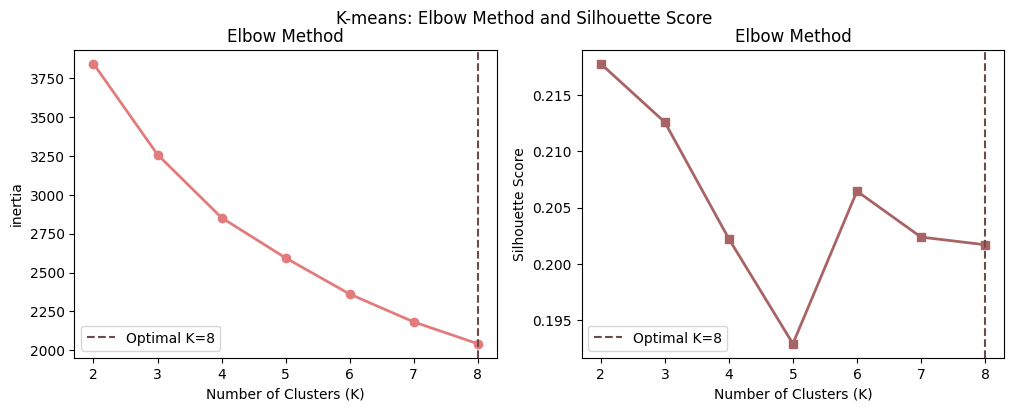

In [13]:
#Visualizations

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("K-means: Elbow Method and Silhouette Score")

axes[0].plot(list(K_range), inertia, "o-", color=PALETTE[0], lw=2)
axes[0].axvline(optimal_k, ls="--", color=PALETTE[2], label=f"Optimal K={optimal_k}")
axes[0].set(xlabel="Number of Clusters (K)", ylabel="inertia", title="Elbow Method")
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, "s-", color=PALETTE[1], lw=2)
axes[1].axvline(optimal_k, ls="--", color=PALETTE[2], label=f"Optimal K={optimal_k}")
axes[1].set(xlabel="Number of Clusters (K)", ylabel="Silhouette Score", title="Elbow Method")
axes[1].legend()



Text(0.5, 1.0, 'Segment Share')

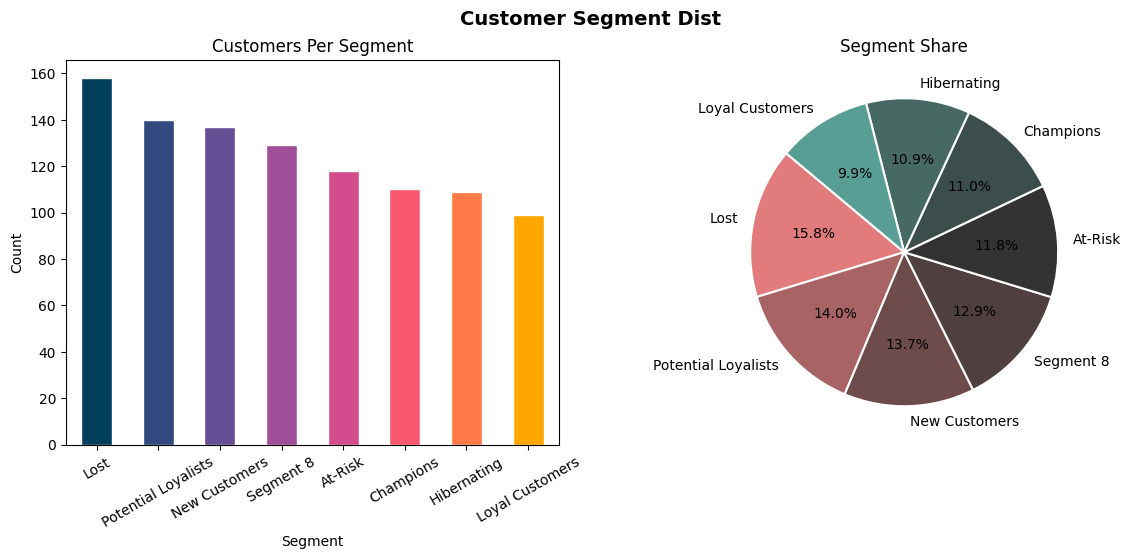

In [14]:
seg_counts = rfm["segment"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle ("Customer Segment Dist", fontsize=14, fontweight="bold")

seg_counts.plot(kind="bar", ax=axes[0], color=PALETTE2[:len(seg_counts)], edgecolor="white")
axes[0].set(title="Customers Per Segment", xlabel="Segment", ylabel="Count")
axes[0].tick_params(axis="x", rotation=30)

axes[1].pie(seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
            colors=PALETTE[:len(seg_counts)], startangle=140, 
            wedgeprops={"edgecolor":"white", "linewidth":1.5})
axes[1].set_title("Segment Share")





Text(0.5, 1.0, 'Segment Profile Heatmap(normalised features)')

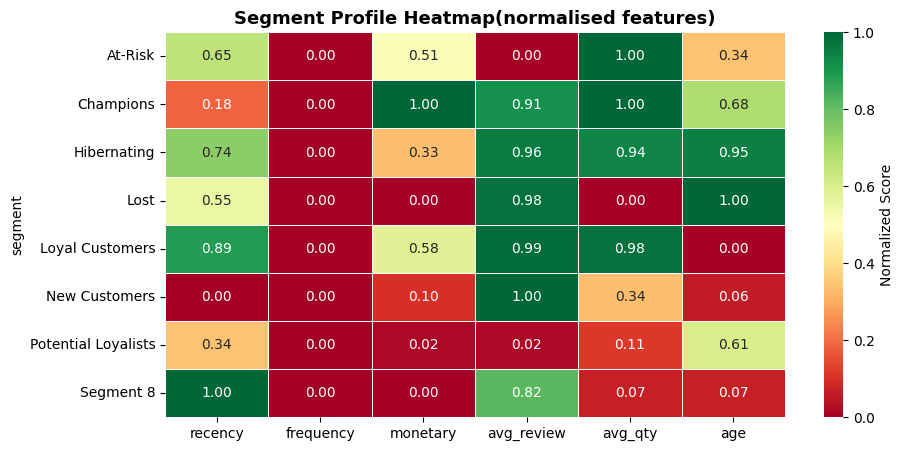

In [15]:
heat_data = (rfm.groupby("segment")[features]
             .mean()
             .apply(lambda c: (c - c.min()) / (c.max() - c.min() + 1e-9)))

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap (heat_data, annot=True, fmt=".2f", cmap="RdYlGn", 
            linewidths=0.5, ax=ax, cbar_kws={"label":"Normalized Score"})
ax.set_title("Segment Profile Heatmap(normalised features)", fontsize=13, fontweight="bold")



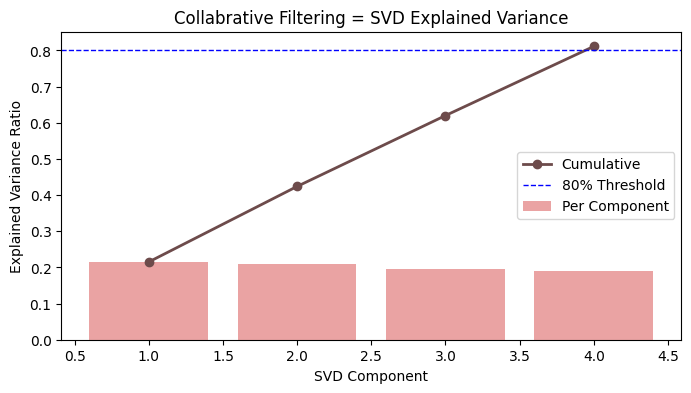

In [18]:
cumvar = np.cumsum(svd.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cumvar)+1), svd.explained_variance_ratio_, 
       color=PALETTE[0], alpha=0.7,label="Per Component")
ax.plot(range(1, len(cumvar)+1),cumvar, "o-", color=PALETTE[2], lw=2,label="Cumulative")
ax.axhline(0.8, ls="--", color="blue", lw=1, label="80% Threshold")
ax.set(xlabel="SVD Component", ylabel="Explained Variance Ratio", title="Collabrative Filtering = SVD Explained Variance")
ax.legend()

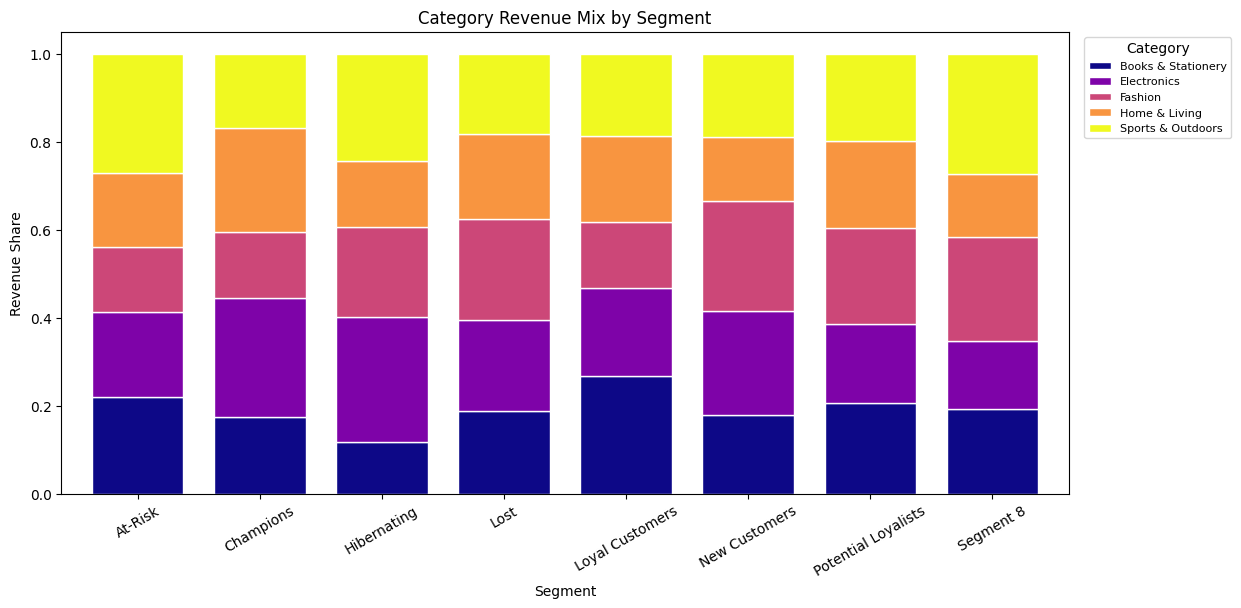

In [27]:
dataf_seg = customer_df.merge(rfm[["customer_id","segment"]], on="customer_id")
cat_seg = dataf_seg.groupby(["segment", "category_name"])["revenue"].sum().unstack(fill_value=0)
cat_norm = cat_seg.div(cat_seg.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 6))
cat_norm.plot(kind="bar", stacked=True, ax=ax, colormap="plasma", edgecolor="white", width=0.75)
ax.set(title="Category Revenue Mix by Segment", xlabel="Segment", ylabel="Revenue Share")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Category", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viri